In [2]:
import pandas as pd

In [3]:
df=pd.read_csv('deliverytime.csv')

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,30
...,...,...,...,...,...,...,...,...,...
45588,7C09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,32
45589,D641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,36
45590,4F8D,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,16
45591,5EEE,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,26


In [23]:
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Time_taken(min)                0
dtype: int64

In [25]:
df.drop(['Type_of_order','Delivery_person_ID','ID','Type_of_vehicle'], axis=1, inplace=True)

KeyError: "['Type_of_order', 'Type_of_vehicle'] not found in axis"

In [13]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Time_taken(min)'],
      dtype='str')

In [12]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.632367,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.327708,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,54.000000


In [14]:
x=df.drop('Time_taken(min)',axis=1)
y=df['Time_taken(min)']
x


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982
...,...,...,...,...,...,...,...,...
45588,7C09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257
45589,D641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000
45590,4F8D,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439
45591,5EEE,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241


In [15]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

ValueError: could not convert string to float: '9F31'

In [17]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_train_scaled)



NameError: name 'x_train_scaled' is not defined

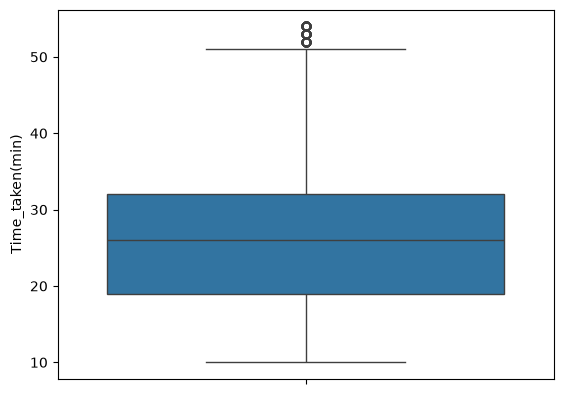

In [13]:
sns.boxplot(df['Time_taken(min)'])
plt.show()

In [29]:
print(df['Type_of_order'].unique())

<StringArray>
['Snack ', 'Drinks ', 'Buffet ', 'Meal ']
Length: 4, dtype: str


In [31]:
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Type_of_order                  0
Type_of_vehicle                0
Time_taken(min)                0
dtype: int64

In [ ]:
from scipy import stats
t_stat, p_value = stats.ttest_ind(df['Type_of_order'],df['Type_of_vehicle'])

TypeError: unsupported operand type(s) for /: 'str' and 'int'

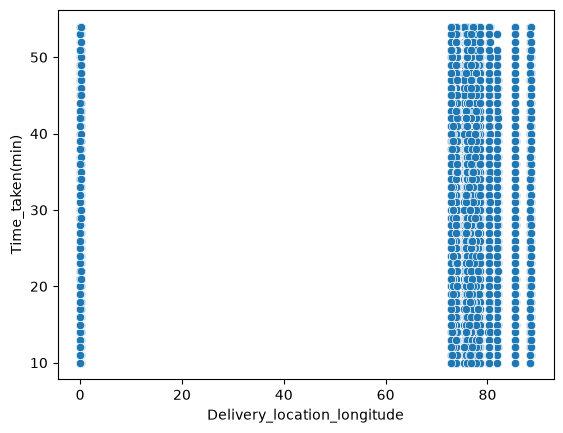

In [14]:
sns.scatterplot(x='Delivery_location_longitude',y='Time_taken(min)',data=df)
plt.show()

In [15]:
corr=df[['Delivery_location_longitude','Restaurant_latitude','Delivery_location_longitude','Time_taken(min)']].corr
corr

<bound method DataFrame.corr of        Delivery_location_longitude  Restaurant_latitude  \
0                        75.912471            22.745049   
1                        77.813237            12.913041   
2                        77.688400            12.914264   
3                        77.026494            11.003669   
4                        80.289982            12.972793   
...                            ...                  ...   
45588                    75.804257            26.902328   
45589                     0.070000             0.000000   
45590                    80.272439            13.022394   
45591                    77.026241            11.001753   
45592                    85.405731            23.351058   

       Delivery_location_longitude  Time_taken(min)  
0                        75.912471               24  
1                        77.813237               33  
2                        77.688400               26  
3                        77.026494         